# ALeRCE ZTF Light Curve Plotter
This notebook shows two ways to get and plot ZTF difference-image light curves from ALeRCE:
1. **Via the `alerce` Python client** (recommended — no manual download needed)
2. **From a manually downloaded CSV** (if you've already downloaded it from the ALeRCE web UI)

## Install dependencies (run once)

In [1]:
!pip install alerce matplotlib pandas

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Band colour conventions used by ZTF / ALeRCE
BAND_COLORS = {
    'g': '#2ca02c',   # green
    'r': '#d62728',   # red
    'i': '#ff7f0e',   # orange
    1:   '#2ca02c',
    2:   '#d62728',
    3:   '#ff7f0e',
}
BAND_LABELS = {1: 'g', 2: 'r', 3: 'i', 'g': 'g', 'r': 'r', 'i': 'i'}

---
## Method 1 — ALeRCE Python Client
Fetches detections and non-detections directly from the ALeRCE API.

In [124]:
from alerce.core import Alerce
import pandas as pd

alerce = Alerce()

OIDS = [
    #"ZTF22abewydn", #CV
    #"ZTF23aapogvn", #Example SN
    #"ZTF21acpfndw", #SNIa detected
    #"ZTF20aapchqy", #SNII detected
    #"ZTF24aahkzvn", #Unclassified
    #"ZTF24abgoksi", #dimmad
    #"ZTF24abrirtr", #dimmad2
    #"ZTF22aajbpuo", #dimmadbogus
    "ZTF22aakdbia",
    "ZTF24aaemydm",
]

lc_data = {}
for oid in OIDS:
    det     = alerce.query_detections(oid, format="pandas", sort="mjd")
    non_det = alerce.query_non_detections(oid, format="pandas", sort="mjd")
    lc_data[oid] = {"det": det, "non_det": non_det}
    print(f"{oid}: {len(det)} detections, {len(non_det)} non-detections")

ZTF22aakdbia: 46 detections, 45 non-detections
ZTF24aaemydm: 30 detections, 7 non-detections


In [114]:
for oid in OIDS:
    det = lc_data[oid]["det"]
    det['mag_plot'] = det['magpsf_corr'].fillna(det['magpsf'])
    det['err_plot'] = det['sigmapsf_corr'].fillna(det['sigmapsf'])
    lc_data[oid]["det"] = det

KeyError: 'magpsf_corr'

In [120]:
# Preview columns available
det = lc_data[OIDS[0]]["det"]
#print("Detection columns:", det.columns.tolist())
#det.head()

In [126]:
for oid in OIDS:
    det = lc_data[oid]["det"]
    print(f"\n{oid}")
    print(f"Total detections: {len(det)}")
    print(f"fid counts: {det['fid'].value_counts().to_dict()}")
    print(f"magpsf_corr non-null: {det['magpsf_corr'].notna().sum()}")
    print(f"magpsf non-null: {det['magpsf'].notna().sum()}")


ZTF22aakdbia
Total detections: 46
fid counts: {1: 26, 2: 20}
magpsf_corr non-null: 46
magpsf non-null: 46

ZTF24aaemydm
Total detections: 30
fid counts: {1: 16, 2: 14}
magpsf_corr non-null: 23
magpsf non-null: 30


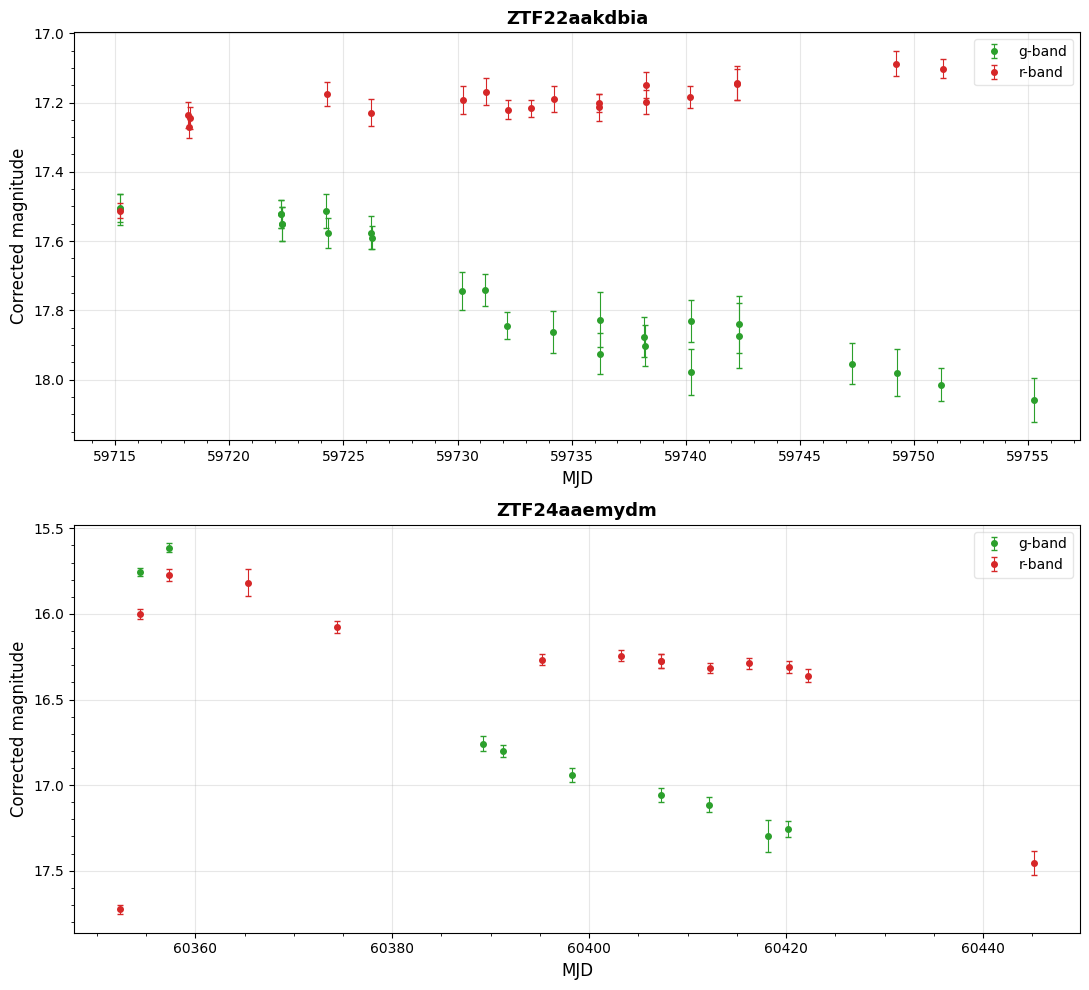

Saved to lightcurves.pdf


In [128]:
def plot_alerce_lc(oid, det, ax=None, title=None):
    """Plot corrected difference-image light curve for one ALeRCE object."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    # Choose magnitude column: prefer corrected, fall back to raw PSF mag
    mag_col  = "magpsf_corr"  if "magpsf_corr"  in det.columns else "magpsf"
    err_col  = "sigmapsf_corr" if "sigmapsf_corr" in det.columns else "sigmapsf"
    time_col = "mjd"
    #mag_col = "mag_plot"
    #err_col = "err_plot"

    for fid, group in det.groupby("fid"):
        band  = BAND_LABELS.get(fid, str(fid))
        color = BAND_COLORS.get(fid, "grey")
        good  = group[mag_col].notna() & group[err_col].notna()
        ax.errorbar(
            group.loc[good, time_col],
            group.loc[good, mag_col],
            yerr=group.loc[good, err_col],
            fmt="o", ms=4, color=color, ecolor=color,
            elinewidth=0.8, capsize=2, label=f"{band}-band"
        )
            

    ax.invert_yaxis()  # astronomical convention: brighter = lower mag number
    ax.set_xlabel("MJD", fontsize=12)
    ax.set_ylabel("Corrected magnitude", fontsize=12)
    ax.set_title(title or oid, fontsize=13, fontweight="bold")
    ax.legend(framealpha=0.5)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(True, alpha=0.3)
    return ax

# ── Plot all objects ──────────────────────────────────────────────────────────
n = len(OIDS)
fig, axes = plt.subplots(n, 1, figsize=(11, 5 * n), squeeze=False)

for i, oid in enumerate(OIDS):
    plot_alerce_lc(oid, lc_data[oid]["det"], ax=axes[i, 0])

plt.tight_layout()
plt.savefig("dimmads.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to lightcurves.pdf")

In [ ]:
# ── Set the path to your downloaded CSV ──────────────────────────────────────
CSV_PATH = "ZTF22abewydn.csv"   # change this to your actual filename
OID_NAME = "ZTF22abewydn"       # used for the plot title
# ─────────────────────────────────────────────────────────────────────────────

df_csv = pd.read_csv(CSV_PATH)
print("Columns:", df_csv.columns.tolist())
print(f"{len(df_csv)} rows loaded")
df_csv.head()

In [ ]:
def plot_csv_lc(df, oid_name):
    """
    Plot from a CSV downloaded from the ALeRCE web interface.
    The CSV typically has columns: mjd, magpsf_corr, sigmapsf_corr, fid,
    and optionally non_det (bool) and diffmaglim.
    """
    fig, ax = plt.subplots(figsize=(11, 5))

    # Split detections from non-detections if the column exists
    if "non_det" in df.columns:
        det     = df[~df["non_det"].astype(bool)].copy()
        non_det = df[ df["non_det"].astype(bool)].copy()
    else:
        det     = df.copy()
        non_det = pd.DataFrame()

    mag_col = "magpsf_corr" if "magpsf_corr" in det.columns else "magpsf"
    err_col = "sigmapsf_corr" if "sigmapsf_corr" in det.columns else "sigmapsf"

    for fid, group in det.groupby("fid"):
        band  = BAND_LABELS.get(fid, str(fid))
        color = BAND_COLORS.get(fid, "grey")
        good  = group[mag_col].notna() & group[err_col].notna()
        ax.errorbar(
            group.loc[good, "mjd"],
            group.loc[good, mag_col],
            yerr=group.loc[good, err_col],
            fmt="o", ms=4, color=color, ecolor=color,
            elinewidth=0.8, capsize=2, label=f"{band}-band"
        )

    if not non_det.empty and "diffmaglim" in non_det.columns:
        for fid, group in non_det.groupby("fid"):
            color = BAND_COLORS.get(fid, "grey")
            ax.scatter(group["mjd"], group["diffmaglim"],
                       marker="v", s=20, color=color, alpha=0.35)

    ax.invert_yaxis()
    ax.set_xlabel("MJD", fontsize=12)
    ax.set_ylabel("Corrected magnitude", fontsize=12)
    ax.set_title(oid_name, fontsize=13, fontweight="bold")
    ax.legend(framealpha=0.5)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{oid_name}_from_csv.pdf", dpi=150, bbox_inches="tight")
    plt.show()

plot_csv_lc(df_csv, OID_NAME)

In [ ]:
# ── Edit this dict: {OID: csv_filename} ──────────────────────────────────────
CSV_FILES = {
    "ZTF22abewydn": "ZTF22abewydn.csv",
    # "ZTF18abcdefg": "ZTF18abcdefg.csv",
}
# ─────────────────────────────────────────────────────────────────────────────

n = len(CSV_FILES)
fig, axes = plt.subplots(n, 1, figsize=(11, 5 * n), squeeze=False)

for i, (oid, path) in enumerate(CSV_FILES.items()):
    df = pd.read_csv(path)

    det     = df[~df["non_det"].astype(bool)] if "non_det" in df.columns else df
    non_det = df[ df["non_det"].astype(bool)]  if "non_det" in df.columns else pd.DataFrame()

    mag_col = "magpsf_corr" if "magpsf_corr" in det.columns else "magpsf"
    err_col = "sigmapsf_corr" if "sigmapsf_corr" in det.columns else "sigmapsf"

    ax = axes[i, 0]
    for fid, group in det.groupby("fid"):
        band  = BAND_LABELS.get(fid, str(fid))
        color = BAND_COLORS.get(fid, "grey")
        good  = group[mag_col].notna() & group[err_col].notna()
        ax.errorbar(group.loc[good, "mjd"], group.loc[good, mag_col],
                    yerr=group.loc[good, err_col],
                    fmt="o", ms=4, color=color, ecolor=color,
                    elinewidth=0.8, capsize=2, label=f"{band}")

    if not non_det.empty and "diffmaglim" in non_det.columns:
        for fid, group in non_det.groupby("fid"):
            ax.scatter(group["mjd"], group["diffmaglim"],
                       marker="v", s=18, color=BAND_COLORS.get(fid, "grey"), alpha=0.35)

    ax.invert_yaxis()
    ax.set_xlabel("MJD"); ax.set_ylabel("Magnitude")
    ax.set_title(oid, fontweight="bold")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("all_lightcurves.pdf", dpi=150, bbox_inches="tight")
plt.show()